In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Loading and Preprocessing

In [2]:
# Load the Iris dataset from sklearn.
iris_data = load_iris()
# The feature data is stored in the '.data' attribute as a NumPy array
# The species information is in the separate '.target' attribute
X = iris_data.data
df = pd.DataFrame(X, columns = iris_data.feature_names)

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [5]:
df.shape

(150, 4)

In [6]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
142,5.8,2.7,5.1,1.9


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df = df.drop_duplicates()

In [12]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

<Axes: >

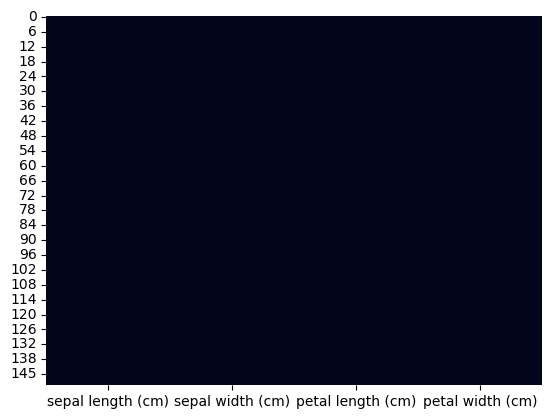

In [13]:
sns.heatmap(df.isnull(), cbar = False)

##### Initial Observation:
The dataset has 150 rows and 4 columns.
No missing values.
Removed one duplicated row.

We now have clean and well formated DataFrame, so DtaFrame is ready to visualize.

#### Data Visualization

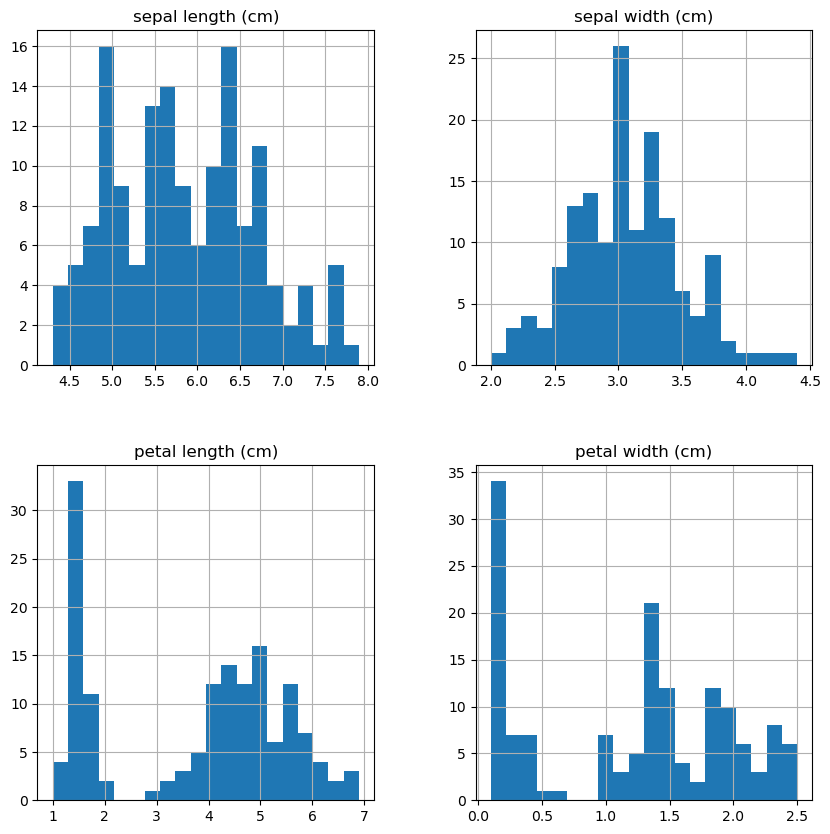

In [14]:
# Plot histograms for each feature to check data spread and skewness
df.hist(bins = 20, figsize = (10, 10))
plt.show()

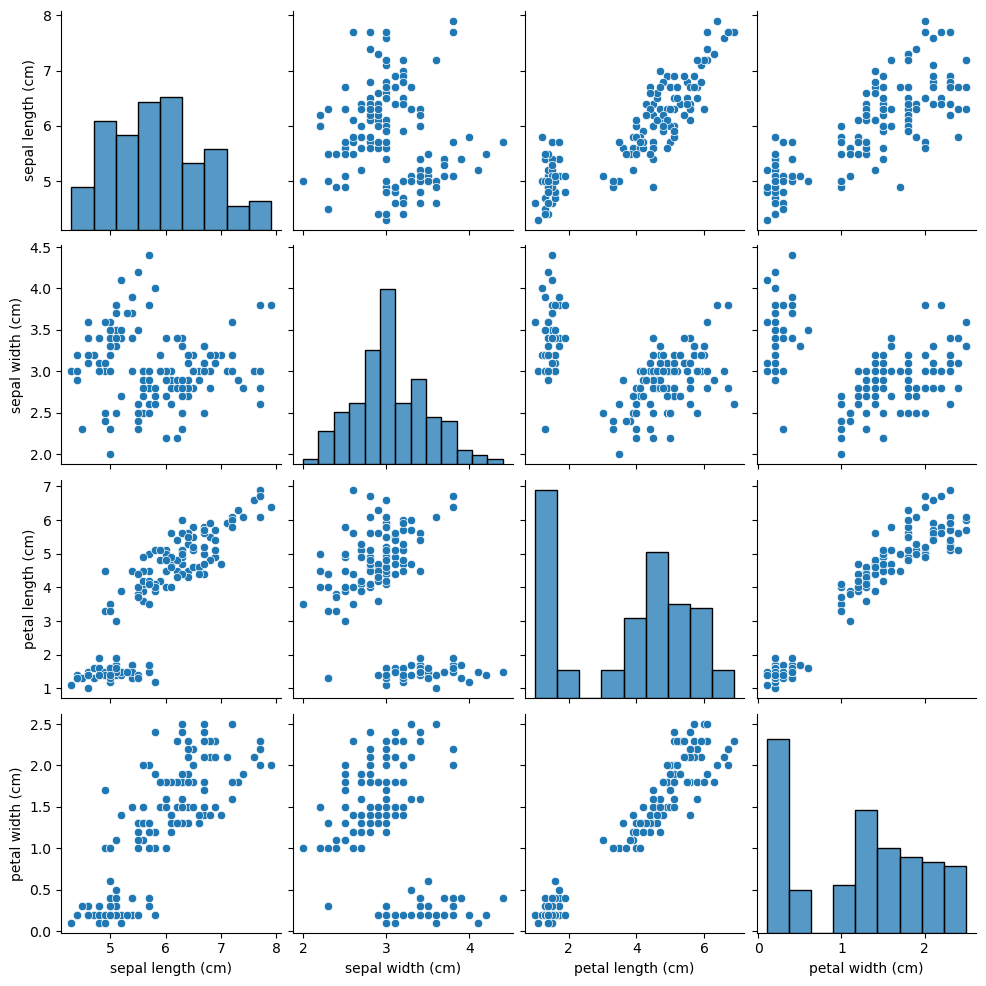

In [15]:
sns.pairplot(df)

#### Scalling

In [16]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [17]:
# Standardization is important for distance-based algorithms
sc = StandardScaler()
x = sc.fit_transform(X)

In [18]:
x

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

## Clustering Algorithm Implementation

### 1. KMeans Clustering

###### Working of KMeans clustering:
K-Means clustering is an iterative, unsupervised machine learning algorithm that groups unlabeled datasets into a pre-defined number (K) of clusters based on feature similarity.
Steps:
1. Initialization: The user specifies the number of clusters, Then, random data points are selected from the dataset to serve as the initial cluster centers (centroids). A common, more robust initialization method is K-Means++.
2. Assignment (E-step): Each data point in the dataset is assigned to the cluster whose centroid is nearest to it, typically using the Euclidean distance metric.
3. Update (M-step): The centroids are recomputed by calculating the mean position of all data points assigned to each specific cluster.
4. Iteration: Steps 2 and 3 are repeated until the centroids no longer move significantly or the cluster assignments stop changing. This indicates the algorithm has converged to a stable solution.

In [19]:
# We know there are 3 species, so we set n_clusters=3
model = KMeans(n_clusters = 3,
               init = 'k-means++',
               max_iter = 300,
               n_init = 10,
               random_state = 42)
y_kmeans = model.fit_predict(x) # Cluster labels assigned by K-Means

C:\Users\farza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


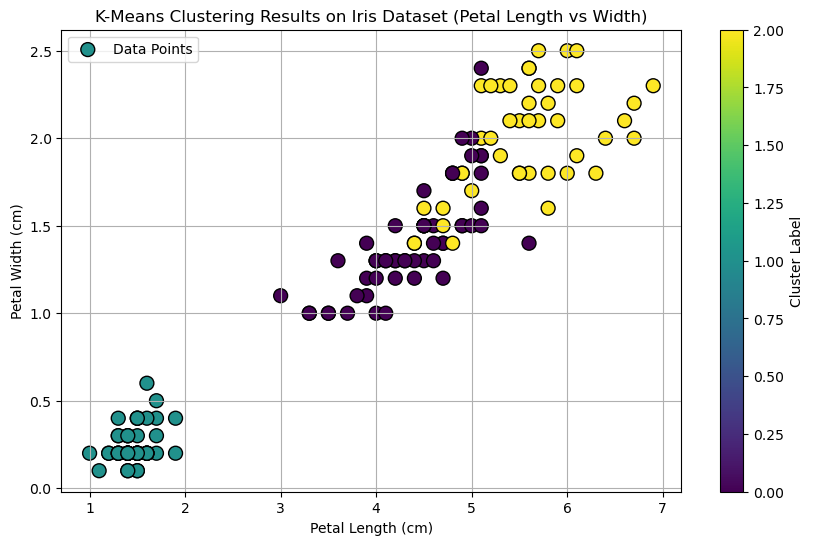

In [20]:
# Visualize the Clusters
# For simplicity, we plot the points on two main features (e.g., Petal Length and Width)
plt.figure(figsize=(10, 6))

# Plot data points with cluster colors
plt.scatter(X[:, 2], X[:, 3], c=y_kmeans, cmap='viridis', edgecolor='k', s=100, label='Data Points')
plt.title("K-Means Clustering Results on Iris Dataset (Petal Length vs Width)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.colorbar(label='Cluster Label')
plt.legend()
plt.grid(True)
plt.show()

###### Why K-Means is Suitable for the Iris Dataset
- Known Number of Clusters: The dataset inherently contains 3 distinct species (Setosa, Versicolor, and Virginica), so the optimal number of clusters, K = 3, is known in advance. This is a primary requirement for the K-Means algorithm.
- Data Characteristics: The Iris dataset has four continuous, numeric features (sepal length/width, petal length/width) and no missing values, making it well-suited for distance-based algorithms like K-Means.
- Cluster Shape Assumption: K-Means assumes that clusters are roughly spherical and have similar sizes. In the Iris dataset, especially when considering certain feature combinations, the species form relatively compact, spherical clusters, allowing K-Means to perform effectively.
- Performance Evaluation: Because the true labels are known, the performance of the unsupervised K-Means algorithm can be easily evaluated by comparing its predicted clusters with the actual species labels.

### 2. Hierarchical Clustering

###### Working of Hierarchical Clustering
Hierarchical clustering is an unsupervised machine learning method that organizes data points into a hierarchy of nested clusters, which can be visualized in a tree-like structure called a dendrogram. The most common approach is agglomerative (bottom-up), which works as follows:
1. Initialization: Each data point starts as its own individual cluster.
2. Distance Calculation: The distances (e.g., Euclidean distance) between all pairs of clusters are computed and stored in a distance matrix.
3. Merging: The two closest (most similar) clusters are identified and merged into a single, larger cluster.
4. Distance Update: The distances between the new cluster and all remaining clusters are recalculated using a chosen linkage method (e.g., Ward's, average, complete, single).
5. Iteration: Steps 3 and 4 are repeated until all data points are combined into one single, all-encompassing cluster.

The sequence of merges is recorded and represented by the dendrogram, where the height of each merge point indicates the distance between the clusters at that step.

###### Why Suitable for the Iris Dataset
- No Predefined Cluster Count: Unlike K-means, it does not require you to specify the number of clusters (k) in advance. The dendrogram allows you to visually determine the optimal number of clusters by cutting the tree at an appropriate height.
- Reveals Structure: The Iris dataset is known to contain three distinct species, and the method's ability to reveal the natural hierarchical relationships within the data aligns well with the biological taxonomy of the flowers.
- Small Dataset Size: Hierarchical clustering can be computationally expensive for very large datasets, but the Iris dataset is small (150 samples), making the method efficient and practical to apply.

In [21]:
# Perform Hierarchical Clustering and create a linkage matrix
linked = linkage(x, method = 'ward') # Ward method minimizes variance

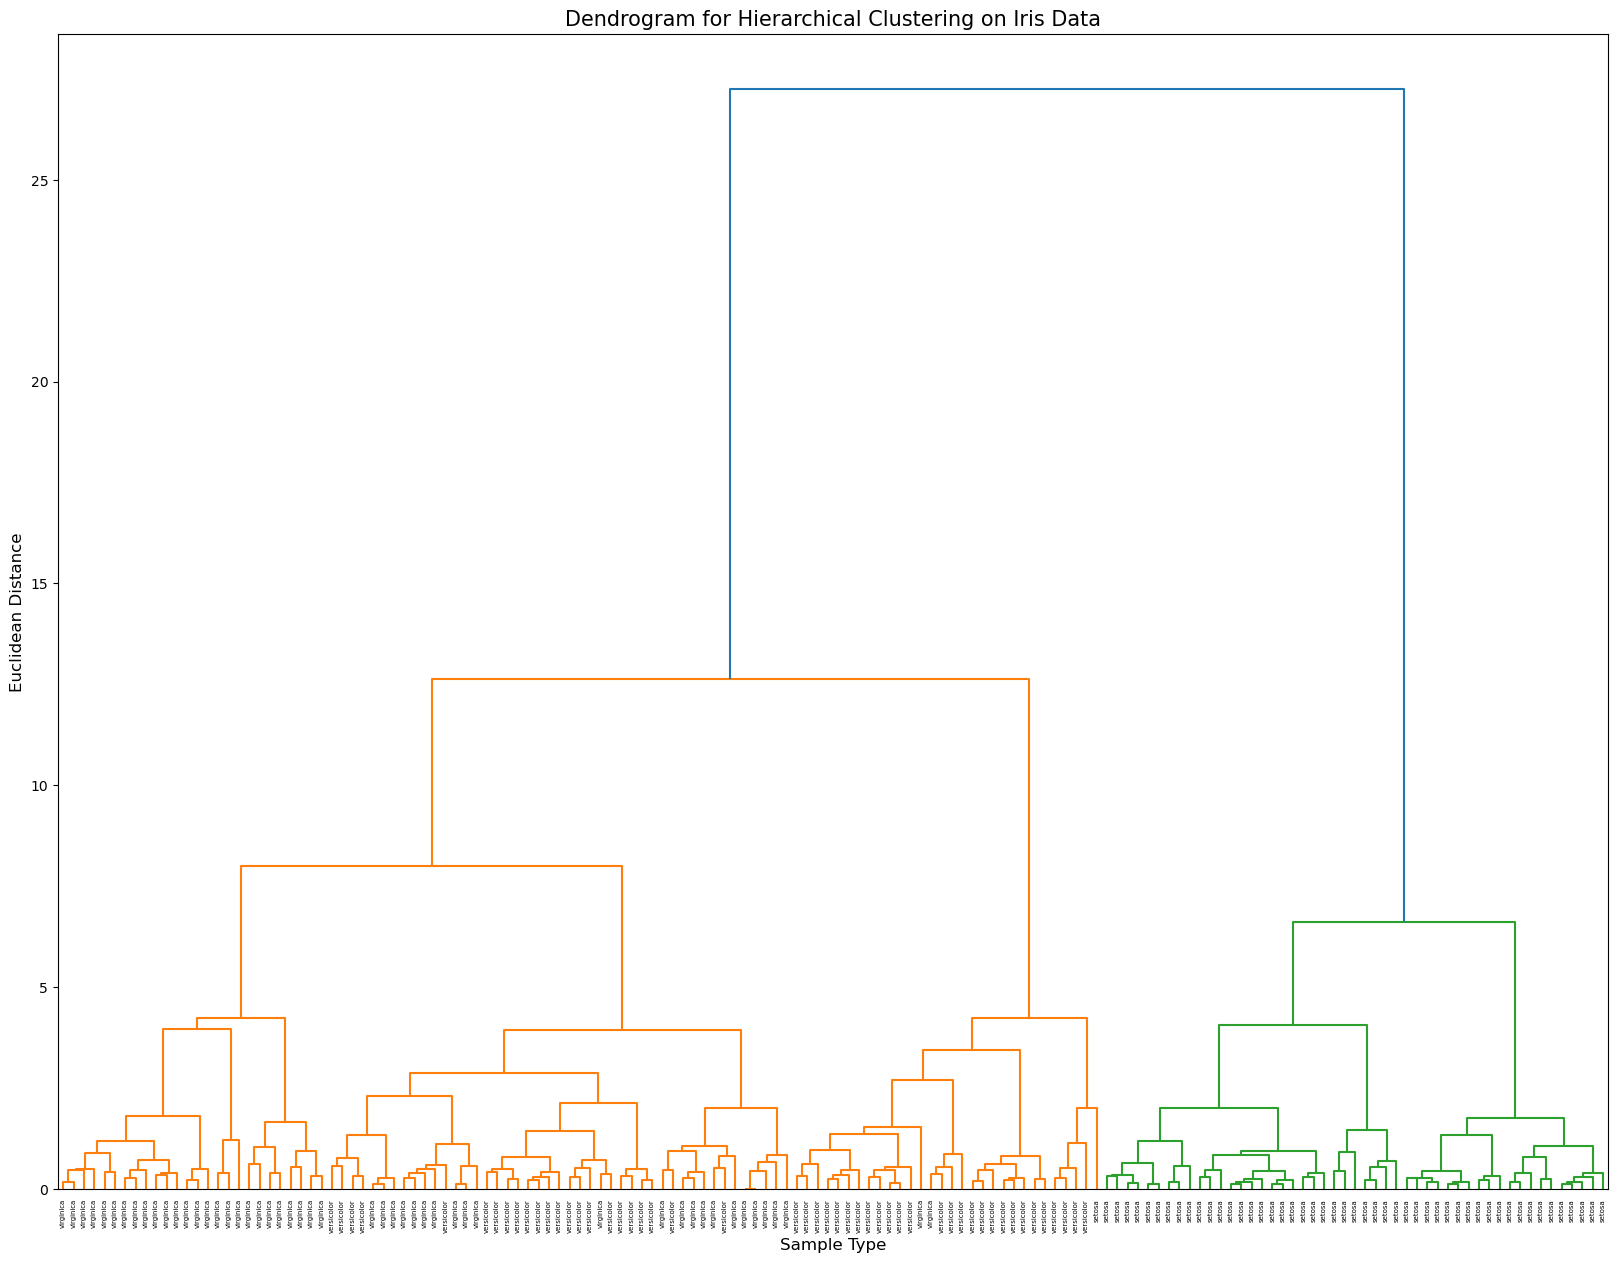

In [22]:
# Plot the dendrogram
plt.figure(figsize = (20, 15))
dendrogram(linked,
            orientation = 'top',
            labels = iris_data.target_names[iris_data.target],
            distance_sort = 'descending',
            show_leaf_counts = True)
plt.title('Dendrogram for Hierarchical Clustering on Iris Data', fontsize = 15)
plt.xlabel('Sample Type', fontsize = 12)
plt.ylabel('Euclidean Distance', fontsize = 12)
plt.show()

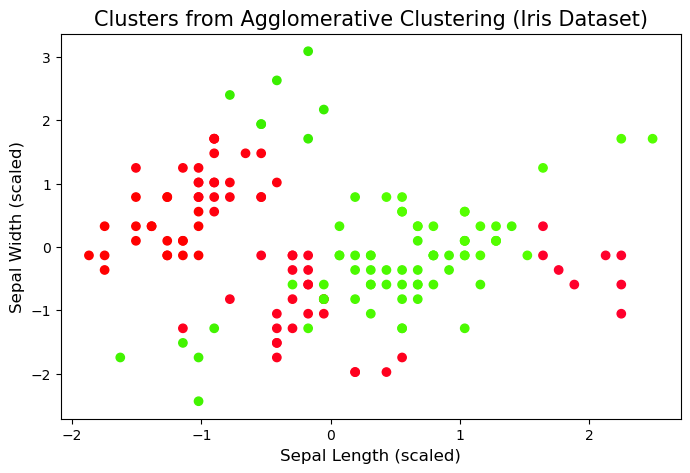

In [23]:
# Form clusters and visualize (using two main features for simplicity)
# A horizontal line on the dendrogram would show a good cut-off around distance 4
threshold = 4
clusters = fcluster(linked, threshold, criterion = 'distance')

plt.figure(figsize = (8, 5))
# Using only the first two features (Sepal Length and Sepal Width) for a 2D scatter plot
plt.scatter(x[:, 0], x[:, 1], c = clusters, cmap = 'prism')
plt.title('Clusters from Agglomerative Clustering (Iris Dataset)', fontsize = 15)
plt.xlabel('Sepal Length (scaled)', fontsize = 12)
plt.ylabel('Sepal Width (scaled)', fontsize = 12)
plt.show()